# Лабораторная работа 14

Тема: **Подбор гиперпараметров и ранняя остановка (PyTorch + Optuna) на MNIST**  
Формат: практическая работа с обязательными собственными экспериментами и текстовыми выводами.

> Этот ноутбук оформлен как задание, а не готовый отчёт.  
> Код даёт каркас, но **основные баллы** ставятся за ваши собственные настройки, графики и объяснения.  
> Текстовые ответы должны быть согласованы с вашими конкретными числами и графиками, а не выглядеть как универсальные формулировки из интернета.


## 1. Ваше понимание гиперпараметров и ранней остановки

До запуска кода сформулируйте (8–12 предложений):

1. Какие величины в нейросетях вы называете **гиперпараметрами**, а какие — **обучаемыми параметрами**.  
2. Зачем вообще подбирать гиперпараметры (learning rate, размер скрытого слоя, dropout) и почему «на глаз» это делать сложно.  
3. Что вы ожидаете от механизма **ранней остановки**: в каких ситуациях он помогает, а когда может мешать добраться до лучшего качества.

Пишите своими словами, не пытаясь угадать «идеальное» определение.


In [2]:
intro_text = """1)В нейросетях я называю гиперпараметрами те параметры, которые я настраиваю до обучения.
  Например,learning rate, размеры слоев и батчей, dropout, количество нейронов, и др.
  А обучаемые параметры - это параметры модели, которые она настраивает во время обучения.
  К таким могут относится: веса, смещения и др.

2)Правильный подбор гиперпараметров сильно влияет на процесс обучения модели.
  Гиперпараметры влияют на общую эффективность обучения, баланс между переобучением и недообучением.
  Подобрать такие параметры "на глаз" сложно, потому что они все влияют друг на друга.
  Для одной модели могут подойти одни, для другой - другие.
  Без перебора гиперпараметров можно не добиться хорошего результата.

3)От механизма ранней остановки я ожидаю, чо он вовремя прекратит обучения, когда качество перестанет расти.
  Механизм помогает бороться с переобучением, сохранив способность хорошо работать не только на тренировочных картинках, но и на новых.
  Ранняя остановка может помешать в случае, когда, например, ошибка на несколько эпох перейдет в плато, но еще сможет дальше снижаться.

"""
print(intro_text)

1)В нейросетях я называю гиперпараметрами те параметры, которые я настраиваю до обучения.
  Например,learning rate, размеры слоев и батчей, dropout, количество нейронов, и др.
  А обучаемые параметры - это параметры модели, которые она настраивает во время обучения.
  К таким могут относится: веса, смещения и др.

2)Правильный подбор гиперпараметров сильно влияет на процесс обучения модели.
  Гиперпараметры влияют на общую эффективность обучения, баланс между переобучением и недообучением.
  Подобрать такие параметры "на глаз" сложно, потому что они все влияют друг на друга.
  Для одной модели могут подойти одни, для другой - другие.
  Без перебора гиперпараметров можно не добиться хорошего результата.

3)От механизма ранней остановки я ожидаю, чо он вовремя прекратит обучения, когда качество перестанет расти.
  Механизм помогает бороться с переобучением, сохранив способность хорошо работать не только на тренировочных картинках, но и на новых.
  Ранняя остановка может помешать в случае

In [2]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.0 MB/s eta 0:00:00


## 2. Импорт, настройки и данные (MNIST)


In [3]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import optuna

import matplotlib.pyplot as plt

MY_SEED = 22
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

# Разобьём train на собственно train и val
val_size = 10000
train_size = len(full_train) - val_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size])

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер val  :", len(val_dataset))
print("Размер test :", len(test_dataset))

Устройство: cuda
MY_SEED = 22


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 507kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]

Размер train: 50000
Размер val  : 10000
Размер test : 10000


## 3. Базовый MLP и класс ранней остановки

Модель: вход 28×28 → скрытый слой → dropout → выход на 10 логитов.


In [4]:
class SimpleMLP(nn.Module):
    def __init__(self, hidden_dim=256, dropout_p=0.2):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(SimpleMLP())

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [5]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
            return False

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

print("Класс EarlyStopping определён.")

Класс EarlyStopping определён.


### Мини‑обсуждение ранней остановки

Опишите в 4–6 предложениях:
- как именно по этому коду принимается решение «останавливать/не останавливать»;  
- почему хранится копия **лучшего** состояния модели, а не только номер эпохи.


In [6]:
es_comment = """Решение по остановке принимается после каждой эпохи.
В каждый шаг передается ошибка на валидаци, если она лучше меньше сохраненной ошибки на min_delta(0), то обновлятся лучшая(меньшая) ошибка, обнуляется счетчик и запоминается текущее состояние.
Если прогресса нет уже 5 эпох, то обучение останавливается.
Хранить копию лучшего состояния модели, а не только номера эпохи стоит для того, чтобы при вызове функции restore_best можно было откатить модель к наивысшему зафиксированному качеству, получив лучшую версию без лишних вычислений.
Если бы запоминалось только эпоха, то пришлось бы заново обучаться модели.
"""
print(es_comment)

Решение по остановке принимается после каждой эпохи.
В каждый шаг передается ошибка на валидаци, если она лучше меньше сохраненной ошибки на min_delta(0), то обновлятся лучшая(меньшая) ошибка, обнуляется счетчик и запоминается текущее состояние.
Если прогресса нет уже 5 эпох, то обучение останавливается.
Хранить копию лучшего состояния модели, а не только номера эпохи стоит для того, чтобы при вызове функции restore_best можно было откатить модель к наивысшему зафиксированному качеству, получив лучшую версию без лишних вычислений.
Если бы запоминалось только эпоха, то пришлось бы заново обучаться модели.



## 4. Вспомогательные функции обучения и валидации


In [7]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 5. Базовый запуск (без Optuna) с ранней остановкой

Сначала обучим одну фиксированную конфигурацию, чтобы увидеть, как работает ранняя остановка и какое качество можно получить без сложного подбора.


In [8]:
base_model = SimpleMLP(hidden_dim=256, dropout_p=0.2).to(device)
base_optimizer = torch.optim.Adam(base_model.parameters(), lr=1e-3)
early_stopper_base = EarlyStopping(patience=5, min_delta=0.0)

max_epochs = 50
history_base = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, max_epochs + 1):
    train_loss, train_acc = train_one_epoch(base_model, train_loader, base_optimizer, device)
    val_loss, val_acc = evaluate(base_model, val_loader, device)

    history_base["train_loss"].append(train_loss)
    history_base["train_acc"].append(train_acc)
    history_base["val_loss"].append(val_loss)
    history_base["val_acc"].append(val_acc)

    print(f"[Base] Эпоха {epoch}/{max_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if early_stopper_base.step(val_loss, base_model):
        print("[Base] Ранняя остановка на эпохе", epoch)
        break

early_stopper_base.restore_best(base_model)
test_loss_base, test_acc_base = evaluate(base_model, test_loader, device)
print(f"[Base] Качество на тесте: loss={test_loss_base:.4f}, acc={test_acc_base:.4f}")

[Base] Эпоха 1/50: train_loss=0.3131, train_acc=0.9092, val_loss=0.1580, val_acc=0.9530
[Base] Эпоха 2/50: train_loss=0.1433, train_acc=0.9575, val_loss=0.1030, val_acc=0.9694
[Base] Эпоха 3/50: train_loss=0.1015, train_acc=0.9698, val_loss=0.0890, val_acc=0.9744
[Base] Эпоха 4/50: train_loss=0.0784, train_acc=0.9764, val_loss=0.0786, val_acc=0.9755
[Base] Эпоха 5/50: train_loss=0.0658, train_acc=0.9792, val_loss=0.0866, val_acc=0.9726
[Base] Эпоха 6/50: train_loss=0.0555, train_acc=0.9825, val_loss=0.0751, val_acc=0.9763
[Base] Эпоха 7/50: train_loss=0.0468, train_acc=0.9848, val_loss=0.0751, val_acc=0.9777
[Base] Эпоха 8/50: train_loss=0.0441, train_acc=0.9855, val_loss=0.0746, val_acc=0.9781
[Base] Эпоха 9/50: train_loss=0.0376, train_acc=0.9875, val_loss=0.0659, val_acc=0.9794
[Base] Эпоха 10/50: train_loss=0.0341, train_acc=0.9888, val_loss=0.0685, val_acc=0.9801
[Base] Эпоха 11/50: train_loss=0.0302, train_acc=0.9900, val_loss=0.0700, val_acc=0.9795
[Base] Эпоха 12/50: train_loss

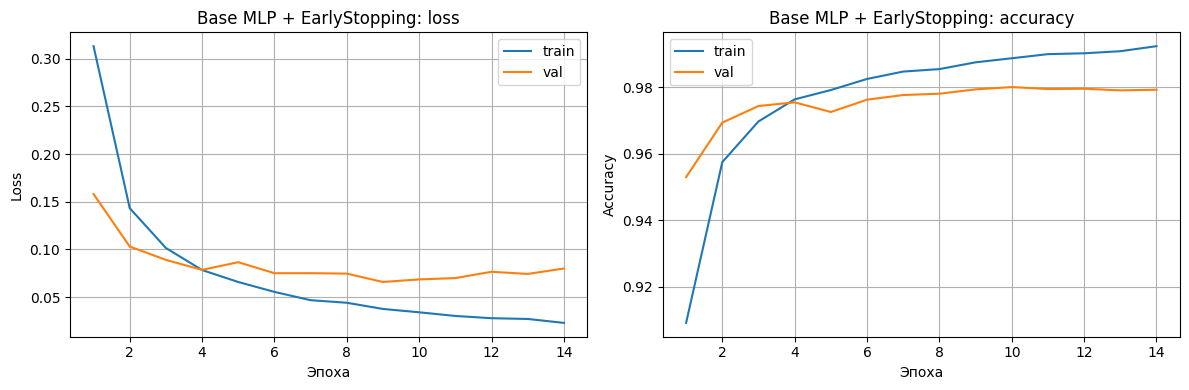

In [9]:
epochs_base = np.arange(1, len(history_base["train_loss"]) + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_base, history_base["train_loss"], label="train")
plt.plot(epochs_base, history_base["val_loss"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Base MLP + EarlyStopping: loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_base, history_base["train_acc"], label="train")
plt.plot(epochs_base, history_base["val_acc"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Base MLP + EarlyStopping: accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Анализ базового запуска

Ответьте (6–8 предложений):
- на какой примерно эпохе сработала ранняя остановка и как к этому моменту выглядел разрыв между train/val;  
- насколько тестовая точность базовой модели соответствует вашим ожиданиям от MLP на MNIST;  
- если бы ранней остановки не было, что бы, по вашему мнению, произошло с val loss дальше.


In [10]:
base_comment = """Ранняя остановка сработала на 14 эпохе.
val_acc не улучшалась уже 4-5 эпох.
В это время train_loss=0.0230, val_loss=0.0800, а разрыв составил ~ 0,57.
Минимальный  val_loss был на 10 эпохе со значением 0.0685.

Тестовая точность составила 98,13%, что соответсвует моим ожиданиям для такой архитектуры модели.

Если бы ранней остановки не было, то по моему мнению, val loss продолжил бы дальше расти или колебаться, а test loss -снижаться, посколько есть потенциал.
Переобучение было бы еще больше,а обобщающая способность падала.
"""
print(base_comment)

Ранняя остановка сработала на 14 эпохе.
val_acc не улучшалась уже 4-5 эпох.
В это время train_loss=0.0230, val_loss=0.0800, а разрыв составил ~ 0,57.
Минимальный  val_loss был на 10 эпохе со значением 0.0685.

Тестовая точность составила 98,13%, что соответсвует моим ожиданиям для такой архитектуры модели.

Если бы ранней остановки не было, то по моему мнению, val loss продолжил бы дальше расти или колебаться, а test loss -снижаться, посколько есть потенциал. 
Переобучение было бы еще больше,а обобщающая способность падала.



## 6. Optuna: постановка задачи оптимизации гиперпараметров

Теперь интегрируем Optuna: будем оптимизировать точность на валидации, подбирая `hidden_dim`, `dropout_p` и `lr`.


In [11]:
def objective(trial: optuna.Trial):
    hidden_dim = trial.suggest_int("hidden_dim", 64, 512, step=64)
    dropout_p = trial.suggest_float("dropout_p", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = SimpleMLP(hidden_dim=hidden_dim, dropout_p=dropout_p).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    early_stopper = EarlyStopping(patience=5, min_delta=0.0)

    max_epochs = 40

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, device)

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if early_stopper.step(val_loss, model):
            break

    early_stopper.restore_best(model)
    _, final_val_acc = evaluate(model, val_loader, device)
    return final_val_acc

print("objective(trial) определена.")

objective(trial) определена.


### Короткий вопрос по постановке задачи оптимизации

Ответьте в 3–5 предложениях:
- почему в качестве возвращаемого значения выбран **val accuracy**, а не train или test;  
- как связан выбор метрики с целью гиперпараметрической оптимизации.


In [12]:
objective_comment = """val accuracy выбрана, потому что валидационная выборка служит честной оценкой обобщающей способности модели
train accuracy может быть высокой за счёт переобучения, но не гарантирует качество на новых данных,
а test accuracy не следует использовать внутри настройки гиперпараметров, чтобы не «подсмотреть» результат и не получить смещённую оптимистичную оценку.

Метрика напрямую определяет направление поиска: оптимизатор будет отдавать предпочтение тем конфигурациям, где модель показывает наибольшую точность на отложенной валидации.
"""
print(objective_comment)

val accuracy выбрана, потому что валидационная выборка служит честной оценкой обобщающей способности модели
train accuracy может быть высокой за счёт переобучения, но не гарантирует качество на новых данных, 
а test accuracy не следует использовать внутри настройки гиперпараметров, чтобы не «подсмотреть» результат и не получить смещённую оптимистичную оценку.

Метрика напрямую определяет направление поиска: оптимизатор будет отдавать предпочтение тем конфигурациям, где модель показывает наибольшую точность на отложенной валидации.



## 7. Запуск Optuna‑поиска и просмотр лучших гиперпараметров


In [13]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20, timeout=None)

print("Число завершённых trials:", len(study.trials))
print("Лучшее значение val accuracy:", study.best_value)
print("Лучшие параметры:")
for k, v in study.best_params.items():
    print("  ", k, "=", v)

[I 2026-05-14 11:05:16,615] A new study created in memory with name: no-name-2d025f60-17c3-40f0-aefa-78d24b7a61e8
[I 2026-05-14 11:07:39,307] Trial 0 finished with value: 0.9788 and parameters: {'hidden_dim': 512, 'dropout_p': 0.3875510373332101, 'lr': 0.0017205605154843992}. Best is trial 0 with value: 0.9788.
[I 2026-05-14 11:09:25,946] Trial 1 finished with value: 0.9666 and parameters: {'hidden_dim': 64, 'dropout_p': 0.04803494785609408, 'lr': 0.004651470980857866}. Best is trial 0 with value: 0.9788.
[I 2026-05-14 11:12:22,546] Trial 2 finished with value: 0.9809 and parameters: {'hidden_dim': 448, 'dropout_p': 0.08660125649429307, 'lr': 0.00045626304022669057}. Best is trial 2 with value: 0.9809.
[I 2026-05-14 11:20:21,469] Trial 3 finished with value: 0.9824 and parameters: {'hidden_dim': 448, 'dropout_p': 0.3621532844055624, 'lr': 0.0001009463106418074}. Best is trial 3 with value: 0.9824.
[I 2026-05-14 11:27:12,123] Trial 4 finished with value: 0.9821 and parameters: {'hidden_

Число завершённых trials: 20
Лучшее значение val accuracy: 0.9826
Лучшие параметры:
   hidden_dim = 512
   dropout_p = 0.4641537639990453
   lr = 0.0007784203558025482


### Краткий комментарий по результатам Optuna

Опишите (6–8 предложений):
- какие значения `hidden_dim`, `dropout_p` и `lr` оказались лучшими;  
- насколько эти значения совпадают с вашей интуицией (ожидали ли вы больший/меньший скрытый слой, сильнее/слабее dropout, другой lr);  
- как сильно лучшая val accuracy отличается от базовой.


In [15]:
optuna_comment = """По итогам 20 испытаний лучшими значениями оказались:
  hidden_dim = 512
  dropout_p = 0.4641537639990453
  lr = 0.0007784203558025482.

По моему ожиданиям hidden_dim оказался очень высоким, больше, чем базовый.
Dropout тоже сильно удивил, так как он почти 0,5.
По моим предположениям оптмимальным значением должно быть 0.2-0.3.
Однако столь агрессивное отключение нейронов позволило большому слою не переобучаться и даже улучшить обобщение.
Скорость обучения тоже чуть ниже базовой, но для сложной модели с большим hidden_dim и высоким dropout было ожидаемо.

Точность на валидации немного превышает базовую модель, где значение val accuracy=0.9793.
При запуске Optuna она составляет 0.9826, что лучше всего на 0,0033.
"""
print(optuna_comment)

По итогам 20 испытаний лучшими значениями оказались:
  hidden_dim = 512
  dropout_p = 0.4641537639990453
  lr = 0.0007784203558025482.

По моему ожиданиям hidden_dim оказался очень высоким, больше, чем базовый. 
Dropout тоже сильно удивил, так как он почти 0,5.
По моим предположениям оптмимальным значением должно быть 0.2-0.3. 
Однако столь агрессивное отключение нейронов позволило большому слою не переобучаться и даже улучшить обобщение.
Скорость обучения тоже чуть ниже базовой, но для сложной модели с большим hidden_dim и высоким dropout было ожидаемо. 

Точность на валидации немного превышает базовую модель, где значение val accuracy=0.9793.
При запуске Optuna она составляет 0.9826, что лучше всего на 0,0033. 



## 8. Финальное обучение лучшей конфигурации и оценка на тесте

Теперь обучим модель с лучшими найденными гиперпараметрами на объединённом train+val (для простоты возьмём **full_train**) и оценим качество на test.


In [16]:
# объединённый train+val = full_train
full_train_loader = DataLoader(full_train, batch_size=batch_size, shuffle=True)

best_hidden_dim = study.best_params["hidden_dim"]
best_dropout_p = study.best_params["dropout_p"]
best_lr = study.best_params["lr"]

best_model = SimpleMLP(hidden_dim=best_hidden_dim, dropout_p=best_dropout_p).to(device)
best_optimizer = torch.optim.Adam(best_model.parameters(), lr=best_lr)
early_stopper_best = EarlyStopping(patience=5, min_delta=0.0)

max_epochs_best = 50
history_best = {"train_loss": [], "train_acc": []}

for epoch in range(1, max_epochs_best + 1):
    train_loss, train_acc = train_one_epoch(best_model, full_train_loader, best_optimizer, device)
    val_loss, val_acc = evaluate(best_model, val_loader, device)  # mini-val из исходного val

    history_best["train_loss"].append(train_loss)
    history_best["train_acc"].append(train_acc)

    print(f"[Best] Эпоха {epoch}/{max_epochs_best}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if early_stopper_best.step(val_loss, best_model):
        print("[Best] Ранняя остановка на эпохе", epoch)
        break

early_stopper_best.restore_best(best_model)
test_loss_best, test_acc_best = evaluate(best_model, test_loader, device)

print(f"[Best] Тестовое качество: loss={test_loss_best:.4f}, acc={test_acc_best:.4f}")
print(f"[Base] Тестовое качество: loss={test_loss_base:.4f}, acc={test_acc_base:.4f}")

[Best] Эпоха 1/50: train_loss=0.3020, train_acc=0.9096, val_loss=0.1214, val_acc=0.9654
[Best] Эпоха 2/50: train_loss=0.1453, train_acc=0.9566, val_loss=0.0865, val_acc=0.9731
[Best] Эпоха 3/50: train_loss=0.1110, train_acc=0.9658, val_loss=0.0594, val_acc=0.9824
[Best] Эпоха 4/50: train_loss=0.0881, train_acc=0.9723, val_loss=0.0442, val_acc=0.9868
[Best] Эпоха 5/50: train_loss=0.0762, train_acc=0.9754, val_loss=0.0367, val_acc=0.9895
[Best] Эпоха 6/50: train_loss=0.0701, train_acc=0.9777, val_loss=0.0305, val_acc=0.9907
[Best] Эпоха 7/50: train_loss=0.0618, train_acc=0.9801, val_loss=0.0258, val_acc=0.9921
[Best] Эпоха 8/50: train_loss=0.0581, train_acc=0.9808, val_loss=0.0222, val_acc=0.9937
[Best] Эпоха 9/50: train_loss=0.0515, train_acc=0.9836, val_loss=0.0186, val_acc=0.9950
[Best] Эпоха 10/50: train_loss=0.0481, train_acc=0.9838, val_loss=0.0184, val_acc=0.9946
[Best] Эпоха 11/50: train_loss=0.0471, train_acc=0.9841, val_loss=0.0156, val_acc=0.9957
[Best] Эпоха 12/50: train_loss

### Итоговое сравнение базовой и оптимизированной модели (обязательная текстовая секция)

Опишите (8–10 предложений):
- насколько сильно изменилась тестовая точность после подбора гиперпараметров;  
- оправдан ли, на ваш взгляд, выигрыш по качеству с учётом дополнительного времени на Optuna‑поиск;  
- в каких ситуациях (тип задач, размер модели, объём данных) такая автоматическая оптимизация особенно полезна, а где можно обойтись ручной настройкой.


In [17]:
final_compare_comment = """Тестовая точность выросла с 0.9813 до 0.9840, прирост при этом составил всего 0.27.
На мой взгляд, выигрыш по качеству не оправдывает многократные затраты на Optuna‑поиск.
В лучше модели при этом обучение остановилось на 47 эпохе, тогда как в базовой на 14.
Такой выигрыш в качестве вряд ли оправдывает потраченные вычислительные ресурсы для задачи MNIST с простым MLP.
Автоматический подбор гиперпараметров полезен для более сложных задач, для больших моделей.
В таких случаях ручной подбор гиперпараметров неэффективен, а Optuna способна найти удачные сочетания dropout, скорости обучения и размера слоёв.
В других случах, есть высокая вероятность, что модель с базовыми настройками даст результат не хуже за меньшее время.
"""
print(final_compare_comment)

Тестовая точность выросла с 0.9813 до 0.9840, прирост при этом составил всего 0.27.
На мой взгляд, выигрыш по качеству не оправдывает многократные затраты на Optuna‑поиск.
В лучше модели при этом обучение остановилось на 47 эпохе, тогда как в базовой на 14.
Такой выигрыш в качестве вряд ли оправдывает потраченные вычислительные ресурсы для задачи MNIST с простым MLP.
Автоматический подбор гиперпараметров полезен для более сложных задач, для больших моделей.
В таких случаях ручной подбор гиперпараметров неэффективен, а Optuna способна найти удачные сочетания dropout, скорости обучения и размера слоёв. 
В других случах, есть высокая вероятность, что модель с базовыми настройками даст результат не хуже за меньшее время.



## 9. Идеи для обязательных вариаций в вашей работе

Чтобы лабораторная работа была засчитана, в **своём** варианте вы должны:

- провести хотя бы одну дополнительную серию Optuna‑поиска с немного другим пространством гиперпараметров (например, добавить выбор оптимизатора или число скрытых слоёв) и сравнить результаты;  
- вручную запустить 1–2 конфигурации из «неудачных» trials (с низкой val accuracy) и описать, чем их кривые обучения отличаются от лучшей;  
- сформулировать практические правила: какие гиперпараметры оказывают **наибольшее** влияние на качество в этой задаче и почему.


In [ ]:
final_summary = """КОГДА ВЫ ПРОВЕДЁТЕ СВОИ ДОПОЛНИТЕЛЬНЫЕ ЭКСПЕРИМЕНТЫ,
ИСПОЛЬЗУЙТЕ ЭТУ ЯЧЕЙКУ ДЛЯ ИТОГОВОГО РЕЗЮМЕ: КАКИЕ ГИПЕРПАРАМЕТРЫ
ОКАЗАЛИСЬ КРИТИЧЕСКИМИ, КАК ВЕЛИКА БЫЛА РАЗНИЦА МЕЖДУ ЛУЧШЕЙ И
НЕУДАЧНЫМИ КОНФИГУРАЦИЯМИ И КАКИЕ ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ ПО
ИСПОЛЬЗОВАНИЮ OPTUNA И РАННЕЙ ОСТАНОВКИ ВЫ СДЕЛАЛИ.
у меня по полчаса и больше вычисления делаются, я не дождусь..."""
print(final_summary)